# Homework 5: Land cover mapping using machine learning and NAIP
### Cleaned notebook and predictions by Jamie Song for MUSA 6950

----------------------------------------------------------------

## Preparing the dataset

First, we download the lu_phily data from here: [link](https://utilitiesfiles.s3.us-east-1.amazonaws.com/penn-class/ai-urban-sustainability/data/lu_phily.tif)

... and the NAIP imagery from here: [link](https://utilitiesfiles.s3.us-east-1.amazonaws.com/penn-class/ai-urban-sustainability/data/naip-philly.tif)

Then, we save them in our working directory.


In [ ]:
# set up libraries
import rasterio as rio
from rasterio.mask import mask
from rasterio.enums import Resampling
from rasterio.coords import BoundingBox
from rasterio.plot import show, show_hist, reshape_as_raster, reshape_as_image
from rasterio.windows import Window
import geopandas as gpd
import numpy as np
import random
from shapely.geometry import mapping
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from matplotlib import pyplot as plt
from pygris import requests
import fiona
from fiona.transform import transform_geom

In [ ]:
# check working directory
pwd

'/Users/songj/Documents/GitHub/ai-urban-sustainability/lab6'

## 1. Prepare the dataset for training
We need to pair the NAIP image and label to build the training dataset. In this tutorial, I just use  the existing land cover map in Philadlephia to generate the land cover map and test the accuracy of the image classification method. 

In [ ]:
# load files and check dimensions

naipfile = './naip-philly.tif'
naip_dataset = rio.open(naipfile)
img_rows, img_cols = naip_dataset.shape
img_bands = naip_dataset.count

print(naip_dataset.shape) # dimensions
print(naip_dataset.count) # bands

lu_dataset = rio.open('./lu_phily.tif')

print(lu_dataset.shape)


(30506, 27280)
4
(50146, 44770)


In [ ]:
# check metadata
naip_dataset.meta, lu_dataset.meta

({'driver': 'GTiff',
  'dtype': 'uint8',
  'nodata': None,
  'width': 27280,
  'height': 30506,
  'count': 4,
  'crs': CRS.from_epsg(2272),
  'transform': Affine(3.282111906158346, 0.0, 2660575.1551,
         0.0, -3.2821119058545856, 304939.8064)},
 {'driver': 'GTiff',
  'dtype': 'uint8',
  'nodata': 255.0,
  'width': 44770,
  'height': 50146,
  'count': 1,
  'crs': CRS.from_epsg(2272),
  'transform': Affine(2.0, 0.0, 2660573.4998999997,
         0.0, -2.0, 304943.1693)})

Because the two datasets have different resolutions and dimensions, we need to conduct data cleaning and resampling in order to pair them together.

Here, we will resample the raster data to the same spatial resolution.

In [ ]:
import rasterio
from rasterio.enums import Resampling

naipfile = './naip-philly.tif'
lufile = './lu_phily.tif'

# define file paths
source_raster = lufile  # raster to be resampled
target_raster = naipfile  # reference raster (at desired resolution)
output_raster = "./lu_resample.tif"

# open reference raster to get its transform and resolution
ref = rio.open(target_raster) 
target_transform = ref.transform
target_crs = ref.crs
target_res = ref.res
target_width = ref.width
target_height = ref.height
target_crs, target_transform

(CRS.from_epsg(2272),
 Affine(3.282111906158346, 0.0, 2660575.1551,
        0.0, -3.2821119058545856, 304939.8064))

In [ ]:
# open the source raster to resample
src= rio.open(source_raster)

# read source data
src_data = src.read(1)  # just read first band
source_transform = src.transform

# # define the new transform and size based on the target raster
# new_transform = target_transform

# update the transform with new resolution but keep same extent
new_transform = rio.transform.Affine(
    target_res[0], source_transform.b, source_transform.c,
    source_transform.d, -target_res[1], source_transform.f
)

# compute new raster size (preserve extent, only change resolution)
new_width = int((src.width * src.res[0]) / target_res[0])
new_height = int((src.height * src.res[1]) / target_res[1])

# perform resampling
resampled_data = src.read(
    out_shape=(1, new_height, new_width),  # match target shape
    resampling= Resampling.nearest
)

# to make sure the resample geotiff keeps colors
color_interpretation = src.colorinterp
colormap = src.colormap(1)  # extract color table (only for 1-band rasters)

# update output raster metadata
new_meta = src.meta.copy()
new_meta.update({
    "driver": "GTiff",
    "height": new_height,
    "width": new_width,
    "transform": new_transform,
    "crs": target_crs,
    "count": 1,
    "compress": 'lzw'
})


In [ ]:
# save the resampled raster
with rio.open(output_raster, "w", **new_meta) as dst:
    dst.write(resampled_data)
    
    # just to write the color scheme, make sure the output tiff also has color, from chatgpt
    dst.colorinterp = color_interpretation
    dst.write_colormap(1, colormap)  # apply original colormap
    
print("Resampling completed successfully!")

Resampling completed successfully!


### Find a common region between LU and NAIP

The two datasets may have different bounds, even though they both cover the entirety of Philadelphia. Therefore, we need to clip a common region to make sure the NAIP and land use map are able to be paired together.

We will check the bounds of the datasets, then clip the rasters to match.

In [ ]:
lu_dataset = rio.open('./lu_resample.tif')

# grab resolutions
naip_res = naip_dataset.res
lu_res = lu_dataset.res

# grab bounds
naip_bounds = naip_dataset.bounds
lulc_bounds = lu_dataset.bounds

# print results
naip_res, lu_res, naip_bounds, lulc_bounds

((3.282111906158346, 3.2821119058545856),
 (3.282111906158346, 3.2821119058545856),
 BoundingBox(left=2660575.1551, bottom=204815.7006, right=2750111.1679, top=304939.8064),
 BoundingBox(left=2660573.4998999997, bottom=204651.67579280143, right=2750112.7948119054, top=304943.1693))

In [13]:
lu_dataset.shape, naip_dataset.shape

((30557, 27281), (30506, 27280))

The two rasters have different sizes and bounds, so we will use the coordinates of pixels to match land use and NAIP pixels in a common region. 

Let's find the bounding box of the common region first.

In [ ]:
# find and print intersection
common_bounds = BoundingBox(
    max(lulc_bounds.left, naip_bounds.left),
    max(lulc_bounds.bottom, naip_bounds.bottom),
    min(lulc_bounds.right, naip_bounds.right),
    min(lulc_bounds.top, naip_bounds.top),
)

print("\nCommon Bounds (Overlapping Area):", common_bounds)


Common Bounds (Overlapping Area): BoundingBox(left=2660575.1551, bottom=204815.7006, right=2750111.1679, top=304939.8064)


In [ ]:
def clip_raster(input_raster, output_raster, common_bounds, reference_crs):
    with rio.open(input_raster) as src:
        # ensure bounds are in the same CRS
        src_crs = src.crs
        if src_crs != reference_crs:
            aligned_bounds = transform_bounds(reference_crs, src_crs,
                                              common_bounds.left, common_bounds.bottom,
                                              common_bounds.right, common_bounds.top)
        else:
            aligned_bounds = (common_bounds.left, common_bounds.bottom, common_bounds.right, common_bounds.top)

        # preserve color interpretation and colormap (for LU map)
        color_interpretation = src.colorinterp
        colormap = src.colormap(1) if src.count == 1 else None  # only for single-band rasters

        # convert bounds to a polygon mask
        bbox = [{
            "type": "Polygon",
            "coordinates": [[
                [aligned_bounds[0], aligned_bounds[1]],
                [aligned_bounds[0], aligned_bounds[3]],
                [aligned_bounds[2], aligned_bounds[3]],
                [aligned_bounds[2], aligned_bounds[1]],
                [aligned_bounds[0], aligned_bounds[1]]
            ]]
        }]

        # mask the raster
        out_image, out_transform = mask(src, bbox, crop=True)

        # update metadata
        out_meta = src.meta.copy()
        out_meta.update({
            "driver": "GTiff",
            "height": out_image.shape[1],
            "width": out_image.shape[2],
            "transform": out_transform,
            "compress": "lzw"
        })

        # save masked raster
        with rio.open(output_raster, "w", **out_meta) as dst:
            dst.write(out_image)
            dst.colorinterp = color_interpretation
            if colormap:
                dst.write_colormap(1, colormap)
    
    print(f"Clipped raster saved as {output_raster} with dimensions: {out_image.shape[2]} x {out_image.shape[1]}")
    

# define input raster paths
lulc_path = "./lu_resample.tif"
naip_path = "./naip-philly.tif"

# define output paths
clipped_lulc_path = "./lulc_clipped.tif"
clipped_naip_path = "./naip_clipped.tif"

# get reference CRS from NAIP
with rio.open(naip_path) as ref:
    reference_crs = ref.crs

# apply clip function to both LU and NAIP
clip_raster(lulc_path, clipped_lulc_path, common_bounds, reference_crs)
clip_raster(naip_path, clipped_naip_path, common_bounds, reference_crs)


Clipped raster saved as ./lulc_clipped.tif with dimensions: 27281 x 30507
Clipped raster saved as ./naip_clipped.tif with dimensions: 27280 x 30506


Here, we will confirm whether the NAIP and land use rasters have the same resolution and bounds.

In [ ]:
# open NAIP raster
with rio.open(clipped_naip_path) as naip:
    naip_data = naip.read()
    naip_meta = naip.meta

# open LU raster
with rio.open(clipped_lulc_path) as land_use:
    land_use_data = land_use.read(1)
    land_use_meta = land_use.meta
    

In [18]:
naip_meta, land_use_meta

({'driver': 'GTiff',
  'dtype': 'uint8',
  'nodata': None,
  'width': 27280,
  'height': 30506,
  'count': 4,
  'crs': CRS.from_epsg(2272),
  'transform': Affine(3.282111906158346, 0.0, 2660575.1551,
         0.0, -3.2821119058545856, 304939.8064)},
 {'driver': 'GTiff',
  'dtype': 'uint8',
  'nodata': 255.0,
  'width': 27281,
  'height': 30507,
  'count': 1,
  'crs': CRS.from_epsg(2272),
  'transform': Affine(3.282111906158346, 0.0, 2660573.4998999997,
         0.0, -3.2821119058545856, 304939.88718809414)})

Because rasterio's `mask` function clips the raster based on geometry, which may slightly alter the pixel grid, it can lead to dimension mismatches between the clipped raster and the reference raster. Here, we have a one-pixel difference, so we will resample again to make sure the dimensions match exactly.

In [ ]:
# define file paths
naip_path = clipped_naip_path
land_use_path = clipped_lulc_path
resampled_land_use_path = "./land_use_resampled.tif"

# open the NAIP raster (reference)
with rio.open(naip_path) as naip:
    naip_transform = naip.transform
    naip_crs = naip.crs
    naip_res = naip.res  # Get resolution
    naip_width, naip_height = naip.width, naip.height

# open the LU raster
with rio.open(land_use_path) as land_use:
    land_use_data = land_use.read(1)
    
    # create an empty array to store resampled land use data
    resampled_land_use_data = np.empty((naip_height, naip_width), dtype=land_use_data.dtype)

    # resample land use raster to match NAIP resolution & size
    rio.warp.reproject(
        source=land_use_data,
        destination=resampled_land_use_data,
        src_transform=land_use.transform,
        src_crs=land_use.crs,
        dst_transform=naip_transform,
        dst_crs=naip_crs,
        dst_resolution=naip_res,
        resampling=Resampling.nearest  # use nearest-neighbor for categorical data
    )
    
    # update metadata for new raster
    new_meta = land_use.meta.copy()
    new_meta.update({
        "driver": "GTiff",
        "height": naip_height,
        "width": naip_width,
        "compress": "lzw",
        "transform": naip_transform,
        "crs": naip_crs
    })

    # save the resampled land use raster
    with rio.open(resampled_land_use_path, "w", **new_meta) as dst:
        dst.write(resampled_land_use_data, 1)

print("Resampled Land Use raster saved with matching dimensions to NAIP!")

Resampled Land Use raster saved with matching dimensions to NAIP!


Now, let's confirm that they match, once and for all:

In [ ]:
# open NAIP raster
with rio.open(clipped_naip_path) as naip:
    naip_data = naip.read()
    naip_meta = naip.meta

# open LU raster
with rio.open(resampled_land_use_path) as land_use:
    land_use_data = land_use.read(1)
    land_use_meta = land_use.meta

In [21]:
naip_meta, land_use_meta

({'driver': 'GTiff',
  'dtype': 'uint8',
  'nodata': None,
  'width': 27280,
  'height': 30506,
  'count': 4,
  'crs': CRS.from_epsg(2272),
  'transform': Affine(3.282111906158346, 0.0, 2660575.1551,
         0.0, -3.2821119058545856, 304939.8064)},
 {'driver': 'GTiff',
  'dtype': 'uint8',
  'nodata': 255.0,
  'width': 27280,
  'height': 30506,
  'count': 1,
  'crs': CRS.from_epsg(2272),
  'transform': Affine(3.282111906158346, 0.0, 2660575.1551,
         0.0, -3.2821119058545856, 304939.8064)})

### Building the training dataset
We must now prepare the X (the raster data) and the label vector. We will create an array `X` that contains all the pixels and an array `y` that has all the training labels.

In [ ]:
import random

# get unique land use classes (ignoring invalid values like -9999 or 0)
unique_classes = np.unique(land_use_data)
unique_classes = unique_classes[unique_classes > 0]  # remove invalid values

# set the number of pixels per class
samples_per_class = 500

# create lists to store sampled data
X_list, y_list = [], []

# sample pixels for each land use class
for lc in unique_classes:
    # get all pixels of this land use class
    rows, cols = np.where(land_use_data == lc)
    
    # randomly select 'samples_per_class' pixels if available
    sample_indices = random.sample(range(len(rows)), min(samples_per_class, len(rows)))
    
    for i in sample_indices:
        r, c = rows[i], cols[i]
        X_list.append(naip_data[:, r, c])  # extract NAIP pixel values
        y_list.append(lc)  # corresponding land use class

# convert to numpy arrays
X = np.array(X_list)
y = np.array(y_list)

# split into training and test sets (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

print(f"Final dataset size: {len(X_train)} training samples, {len(X_test)} test samples")


Final dataset size: 2450 training samples, 1050 test samples


In [ ]:
# check dimensions of x and y arrays
X.shape, y.shape

((3500, 4), (3500,))

Now, we will run 5 different machine learning algorithms on these data.
- Support Vector Machine (SVM)
- Random Forest
- k-Nearest Neighbors (kNN)
- Decision Tree
- Naïve Bayes

In [ ]:
# define classifiers
models = {
    "SVM": SVC(kernel="rbf"),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "k-NN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Naïve Bayes": GaussianNB()
}

# train and evaluate each model
for name, model in models.items():
    model.fit(X_train, y_train)
    accuracy = model.score(X_test, y_test)
    print(f"{name}: Accuracy = {accuracy:.4f}")
    

SVM: Accuracy = 0.5257
Random Forest: Accuracy = 0.5000
k-NN: Accuracy = 0.5048
Decision Tree: Accuracy = 0.4257
Naïve Bayes: Accuracy = 0.4429


As we can see, the SVM model outperformed the other models. Because the SVM yielded the highest accuracy, we will proceed to use it in the model.

In [ ]:
gnb = GaussianNB()
gnb.fit(X_train, y_train)

GaussianNB()

In [ ]:
# train an SVM Classifier (RBF Kernel for non-linear decision boundaries)
svm_model = SVC(kernel="rbf", C=10, gamma="scale")
svm_model.fit(X_train, y_train)

# # uncomment to run Phila predictions on the test set
# y_pred = svm_model.predict(X_test)

## Predicting on San Francisco NAIP imagery

With our SVM model, we can now proceed by trying to classify the NAIP imagery for San Francisco.

Now we can predict for each pixel in our image:

In [ ]:
with rio.open('./maskedSF-naip.tif') as src:
    img = src.read()
    meta = src.meta
    
# take our full image and reshape into long 2d array (nrow * ncol, nband) for classification
print(img.shape)
reshaped_img = reshape_as_image(img)
print(reshaped_img.shape)


(4, 19207, 23252)
(19207, 23252, 4)


In [ ]:
class_prediction = model.predict(reshaped_img.reshape(-1, 4))

# reshape our classification map back into a 2D matrix so we can visualize it
class_prediction = class_prediction.reshape(reshaped_img[:, :, 0].shape)

In [42]:
class_prediction.shape

(19207, 23252)

Here, we briefly preview the classification map. A more detailed map is provided along with this notebook.

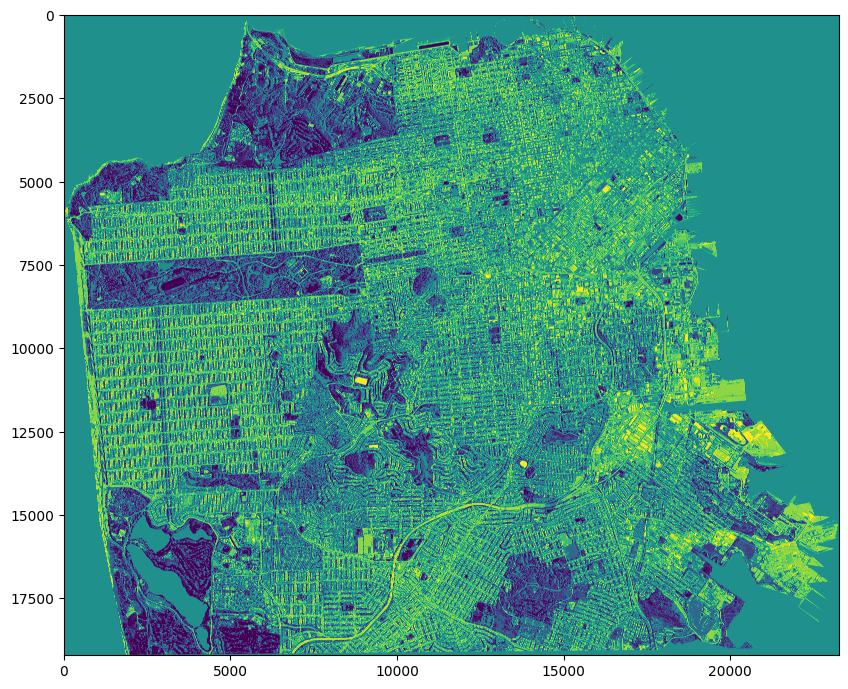

In [43]:
from matplotlib import pyplot as plt

plt.figure(figsize=(10, 10))
plt.imshow(class_prediction)

In [45]:
meta.update({"count": 1})

In [ ]:
# save the classification predictions as a GeoTIFF
output_path = "classified_lulc.tif"
with rio.open(output_path, "w", **meta) as dst:
    dst.write(class_prediction, 1)

We will also use the shapefile of San Francisco to mask the raster and thereby clean up the image.

In [ ]:
# download SF geojson as needed
url = "https://github.com/ResidentMario/geoplot-data/raw/refs/heads/master/san-francisco.geojson"
geojson_path = "san-francisco.geojson"

response = requests.get(url)
with open(geojson_path, "wb") as file:
    file.write(response.content)

input_value_raster = 'classified_lulc.tif'
geojson = 'san-francisco.geojson'
out_raster = 'classified_lulc_masked.tif'

# define the source and target CRS
source_crs = 'EPSG:4326'
target_crs = 'EPSG:26910'

with fiona.open(geojson, "r") as geojson:
    shapes = transform_geom(source_crs, target_crs, [feature["geometry"] for feature in geojson])

with rio.open(input_value_raster) as src:
    out_image, out_transform = mask(src, shapes, crop=True)
    out_meta = src.meta

out_meta.update({"driver": "GTiff",
                 "height": out_image.shape[1],
                 "width": out_image.shape[2],
                 "compress": 'lzw',
                 "transform": out_transform})

with rio.open(out_raster, "w", **out_meta) as dest:
    dest.write(out_image)    

In [ ]:
# the following section can be uncommented to run an accuracy/classification report
# but an actual land use raster must be obtained before this can be run

# from sklearn.metrics import accuracy_score, classification_report

# # Split data into training and testing sets
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# # Train an SVM Classifier (RBF Kernel for non-linear decision boundaries)
# svm_model = SVC(kernel="rbf", C=10, gamma="scale")
# svm_model.fit(X_train, y_train)

# # Predict on the test set
# y_pred = svm_model.predict(X_test)

# # Evaluate Model
# print("Accuracy:", accuracy_score(y_test, y_pred))
# print("Classification Report:\n", classification_report(y_test, y_pred))